In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Алгоритм k-means

Алгоритм k-means является одним из самых популярных методов кластеризации данных. Он используется для разбиения набора данных на \(k\) групп (кластеров) на основе схожести данных. Этот алгоритм особенно полезен в задачах, связанных с сегментацией, упрощением данных и анализом шаблонов.

## Основные шаги алгоритма k-means:

1. **Выбор количества кластеров $k$**:
   - На первом этапе необходимо задать количество кластеров $k$, на которое будет разделен набор данных. Этот параметр обычно выбирается экспериментально.

2. **Инициализация центроидов**:
   - Случайным образом выбираются $k$ точек из данных, которые станут начальными центроидами кластеров. Центроид — это точка, представляющая центр кластера.

3. **Назначение точек кластерам**:
   - Для каждой точки в наборе данных вычисляется расстояние до каждого из $k$ центроидов. Точка присваивается кластеру, центроид которого находится ближе всего к этой точке. В этом шаге обычно используется эвклидово расстояние, но могут применяться и другие метрики расстояния.

4. **Обновление центроидов**:
   - После назначения всех точек пересчитываются центроиды. Новый центроид каждого кластера вычисляется как среднее значение всех точек, принадлежащих этому кластеру.

5. **Повторение шагов 3 и 4**:
   - Шаги 3 и 4 повторяются до тех пор, пока центроиды не перестанут изменяться (или изменения будут незначительными) или пока не будет достигнуто максимальное количество итераций. Это означает, что алгоритм сошелся и кластеры стабилизировались.


## Заключение

Алгоритм k-means является мощным инструментом для кластеризации данных, который используется в различных областях, таких как маркетинг, биоинформатика, обработка изображений и многие другие. Несмотря на свои ограничения, он остается одним из основных методов для решения задач кластеризации.

# Что оптимизирует k_means:

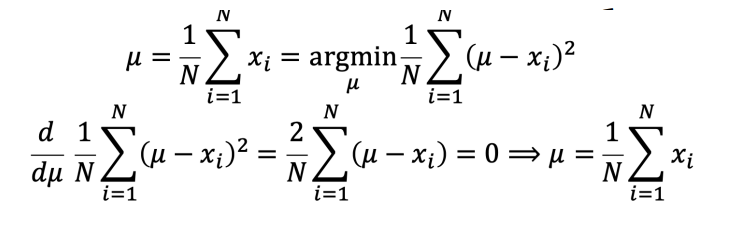

Где $x = \{x_1, x_2, x_3 ... x_n\}$

# Task

Напишите алгоритм кластеризации данных для предложенной выборки с тремя кластерами.

In [149]:
coords = np.concatenate([np.random.randn(100, 2)+np.array([1, 2]),
                         np.random.randn(100, 2)+np.array([-5, 4]),
                         np.random.randn(150, 2)+np.array([3, -5])], axis=0)

In [150]:
coords.shape

(350, 2)

<Axes: >

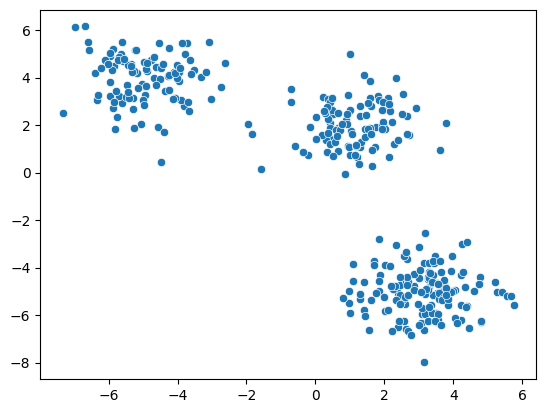

In [151]:
sns.scatterplot(x=coords[:, 0], y=coords[:, 1])

In [152]:
coords.shape

(350, 2)

In [153]:
rng = np.random.default_rng(seed = 42)

In [154]:
centroids = coords[rng.choice(coords.shape[0], size = 3) ]

In [155]:
centroids

array([[ 0.47367093,  2.64688013],
       [ 1.69973291, -3.88581468],
       [ 1.68868598, -3.72896932]])

In [156]:
coords_ = coords.reshape(350, 1, 2)
centroids_ = centroids.reshape(1, 3, 2)
coords_ - centroids_

array([[[ 2.06790115,  0.64351268],
        [ 0.84183917,  7.1762075 ],
        [ 0.85288609,  7.01936213]],

       [[ 0.56637863, -0.8987592 ],
        [-0.65968335,  5.63393561],
        [-0.64863643,  5.47709025]],

       [[ 2.17846358, -0.2525326 ],
        [ 0.9524016 ,  6.28016222],
        [ 0.96344853,  6.12331685]],

       ...,

       [[ 3.15349892, -9.0454181 ],
        [ 1.92743694, -2.51272328],
        [ 1.93848386, -2.66956865]],

       [[ 2.18620554, -7.38933172],
        [ 0.96014355, -0.8566369 ],
        [ 0.97119048, -1.01348227]],

       [[ 1.74826493, -9.31167111],
        [ 0.52220295, -2.77897629],
        [ 0.53324987, -2.93582166]]], shape=(350, 3, 2))

In [157]:
distances = np.linalg.norm(coords_ - centroids_, axis = -1)

In [158]:
labels = np.argmin(distances, axis = 1)
labels[:5]

array([0, 0, 0, 0, 0])

In [159]:
new_centroids = np.array([coords[labels == i].mean(axis = 0) for i in range(3)])
new_centroids

array([[-1.91783799,  2.98025034],
       [ 3.12473958, -5.18261594],
       [ 2.99328671, -3.22385324]])

In [160]:
def k_means(coords, points, max_iter, tolerance = 0.0001):
    centroids = coords[rng.choice(coords.shape[0], size = points)]
    old_labels = None


    for i in range(max_iter):
        distances = np.linalg.norm(coords[:, None, :] - centroids[None, :, :], axis = -1)
        labels = np.argmin(distances, axis = 1)
        new_centroids = np.array([coords[labels == j].mean(axis = 0) for j in range(points)])
        if (np.linalg.norm(centroids - new_centroids, axis = 1).mean() < tolerance) or (np.array_equal(labels, old_labels)):
            centroids = new_centroids
            old_labels = labels
            break
        centroids = new_centroids
        old_labels = labels
    
    return centroids, old_labels

<Axes: >

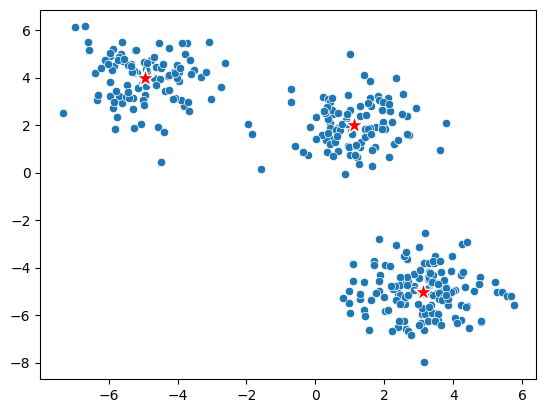

In [165]:
centroids, labels = k_means(coords, 3, 1000)

sns.scatterplot(x=coords[:, 0], y=coords[:, 1])
sns.scatterplot(x=centroids[:, 0], y=centroids[:, 1], s=200, marker='*',color='red')  